In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from pm.utils.data import DataManager

from utils.components import (
    download_macro_factors,
    transform_macro_factors,
    calculate_all_spreads,
    align_to_portfolio

)

from utils.analyzers import (
    MacroFactorAnalyzer,
    MacroCorrelationAnalyzer,
    MacroSensitivityAnalyzer,
    MacroSituationAnalyzer,
    FactorSelectionAnalyzer
)

from utils.reporters import (
    MacroFactorReporter,
    MacroCorrelationReporter,
    MacroSensitivityReporter,
    MacroSituationReporter
)

from utils.visualizations import (
    MacroFactorVisualizer,
    MacroCorrelationVisualizer,
    MacroSensitivityVisualizer,
    MacroSituationVisualizer
)

from utils.tools import (
    MACRO_GLOBAL_FACTORS,
    FACTORS_TO_USE,
    ANNUAL_FACTOR,   
    REGIME_WINDOW     
)

In [2]:
# Inicializar analyzers
factor_analyzer = MacroFactorAnalyzer(annual_factor=ANNUAL_FACTOR)
corr_analyzer = MacroCorrelationAnalyzer(max_lag=126)
sens_analyzer = MacroSensitivityAnalyzer(annual_factor=ANNUAL_FACTOR)
situation_analyzer = MacroSituationAnalyzer()
selector = FactorSelectionAnalyzer(corr_threshold=0.9, vif_threshold=10.0, force_keep=FACTORS_TO_USE)

# Inicializar reporters
factor_reporter = MacroFactorReporter(factor_analyzer)
corr_reporter = MacroCorrelationReporter(corr_analyzer)
sens_reporter = MacroSensitivityReporter(sens_analyzer)
situation_reporter = MacroSituationReporter(situation_analyzer)

# Inicializar visualizers
factor_viz = MacroFactorVisualizer(factor_analyzer)
corr_viz = MacroCorrelationVisualizer(corr_analyzer)
sens_viz = MacroSensitivityVisualizer(sens_analyzer)
situation_viz = MacroSituationVisualizer(situation_analyzer)


In [3]:
TICKERS = ["BTC-EUR", "IONQ", "META"]
WEIGHTS = np.ones(len(TICKERS)) / len(TICKERS)
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

In [4]:
data_manager = DataManager()
assets_prices, _ = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name="SP500",
    start_date=START_DATE,
    end_date=END_DATE
)

returns = assets_prices.pct_change().dropna()
portfolio_returns = (returns * WEIGHTS).sum(axis=1)

print(f"Portfolio returns: {len(portfolio_returns)} observaciones")
print(f"Rango: {portfolio_returns.index[0]} a {portfolio_returns.index[-1]}")

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  3 of 3 completed


Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  1 of 1 completed

Portafolio descargado: 3 activos + benchmark
Portfolio returns: 1003 observaciones
Rango: 2021-01-05 00:00:00 a 2024-12-30 00:00:00


In [5]:
factors_raw = download_macro_factors(
    factor_names=MACRO_GLOBAL_FACTORS, 
    start_date=START_DATE,
    end_date=END_DATE,
    progress=True
)

factors_dict, factors_df = transform_macro_factors(
    factors_raw,
    target_index=portfolio_returns.index
)

spreads_df = calculate_all_spreads(factors_df)

if not spreads_df.empty:
    print(f"Spreads calculados: {spreads_df.shape[1]}")
    print(f"   {', '.join(spreads_df.columns)}")
    factors_complete = pd.concat([factors_df, spreads_df], axis=1)
else:
    print("No hay spreads calculados")
    factors_complete = factors_df.copy()

factors_aligned = align_to_portfolio(factors_complete, portfolio_returns)
factors_for_analysis = factors_aligned[FACTORS_TO_USE + list(spreads_df.columns)].dropna()

print(f"\nFactores para análisis: {factors_for_analysis.shape[1]} factores")
print(f"Observaciones: {factors_for_analysis.shape[0]}")

[*********************100%***********************]  20 of 20 completed


[Macro] OIL: 1 valores <= 0 encontrados, reemplazados por NaN
Spreads calculados: 3
   yield_curve_30_10y, credit_spread_hy, credit_spread_hy_lqd

Factores para análisis: 14 factores
Observaciones: 1003


In [6]:
sel_res = selector.analyze(factors_for_analysis)
pruned_factors = sel_res["pruned_factors"]

print(f"Factores originales: {factors_for_analysis.shape[1]}")
print(f"Factores después de limpieza: {pruned_factors.shape[1]}")
print(f"Factores eliminados: {factors_for_analysis.shape[1] - pruned_factors.shape[1]}")

Factores originales: 14
Factores después de limpieza: 11
Factores eliminados: 3


                      ANÁLISIS DE FACTORES MACRO                      
RESUMEN DE REGRESIÓN
  Alpha (diario):             0.1314%
  Alpha (anual):               39.22%
  R²:                          0.399
  R² ajustado:                 0.392
  Observaciones:                1003
  Interpretación:           Excelente - genera alpha significativo
FACTOR LOADINGS (BETAS)
Factor                     Beta     t-stat    p-value Signif    
SP500                    1.6127     10.183     0.0000 ***       
HYG                      0.4056      1.489     0.1365           
GOVT_20Y                -0.3494     -1.350     0.1772           
DXY                      0.3482      1.442     0.1493           
RATE_2Y                 -0.2453     -1.170     0.2421           
RATE_10Y                -0.2199     -0.402     0.6880           
LQD                      0.2178      0.463     0.6435           
RATE_30Y                -0.1690     -0.320     0.7490           
OIL                     -0.0380     -1.408   

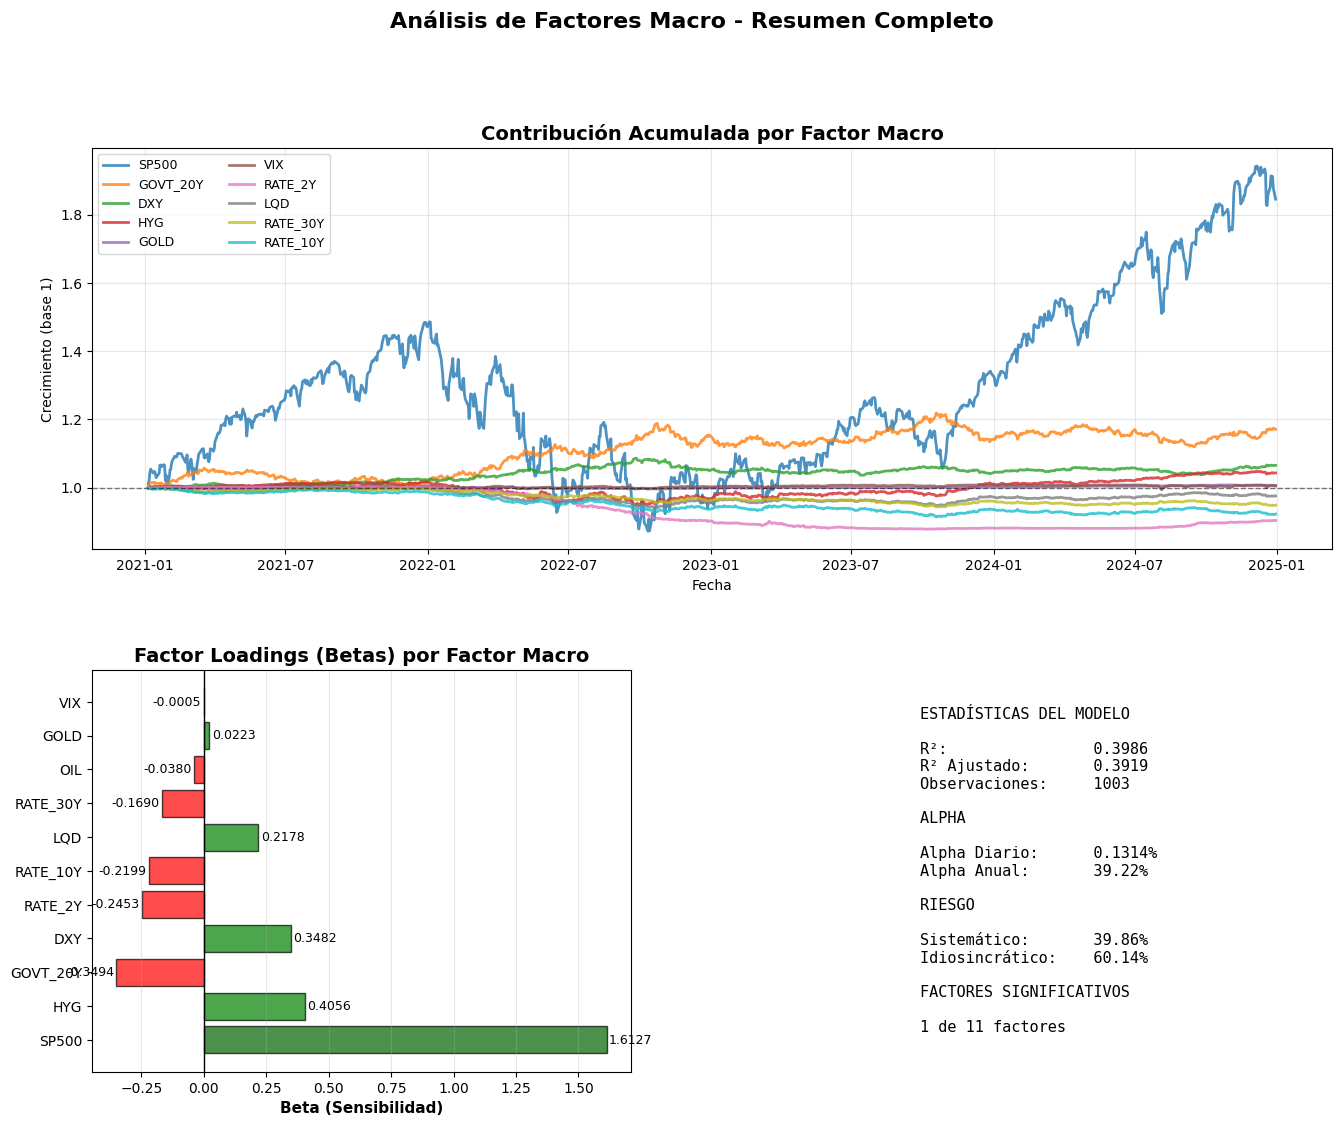

In [7]:
factor_results = factor_analyzer.analyze(
    portfolio_returns,
    pruned_factors,
    use_hac=True
)

factor_reporter.print_analysis(factor_results)
fig = factor_viz.plot_factor_analysis(factor_results, top_n=10)
plt.show()

                   ANÁLISIS DE CORRELACIONES MACRO                    
MEJORES CORRELACIONES (con lag óptimo)
Factor                   Corr    Lag     t-stat    p-value
SP500                   0.626      0     24.397     0.0000
HYG                     0.494      0     16.325     0.0000
VIX                    -0.469      0    -11.063     0.0000
credit_spread_hy_lqd    0.245      0      6.882     0.0000
LQD                     0.245      0      6.865     0.0000
credit_spread_hy        0.209      0      6.345     0.0000
DXY                    -0.194      0     -5.039     0.0000
RATE_10Y               -0.125    113     -3.877     0.0001
RATE_2Y                -0.121    -21     -3.153     0.0016
OIL                    -0.109     59     -3.252     0.0011

FACTORES LEADING (predicen portafolio)
  • RATE_2Y: -21 días adelantado (corr=-0.121)
FACTORES LAGGING (siguen al portafolio)
  • RATE_10Y: 113 días retrasado (corr=-0.125)
  • OIL: 59 días retrasado (corr=-0.109)
  • RATE_30Y: 113 días ret

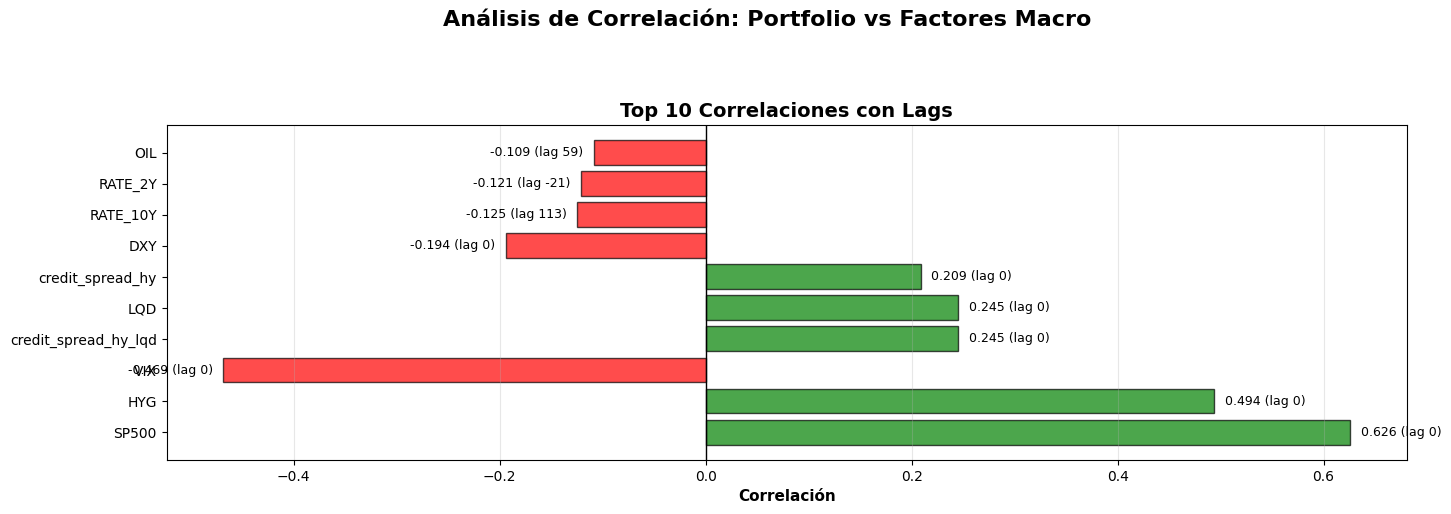

In [8]:
corr_results = corr_analyzer.analyze(
    portfolio_returns,
    factors_for_analysis
)

corr_reporter.print_analysis(corr_results)
fig = corr_viz.plot_correlation_analysis(corr_results, top_n=10)
plt.show()

                   ANÁLISIS DE SENSIBILIDADES MACRO                   
EXPOSICIONES POR MAGNITUD
ALTA EXPOSICIÓN (|β| > 0.5)
  ↑ SP500: β =   1.613
EXPOSICIÓN MODERADA (0.2 ≤ |β| ≤ 0.5)
  ↑ DXY: β =   0.348
  ↑ credit_spread_hy: β =   0.260
  ↓ RATE_2Y: β =  -0.245
  ↓ RATE_10Y: β =  -0.203
BAJA EXPOSICIÓN (|β| < 0.2)
    LQD: β =   0.194
    RATE_30Y: β =  -0.186
    HYG: β =   0.170
    GOVT_20Y: β =  -0.090
    OIL: β =  -0.038
FACTOR DOMINANTE
  SP500: β = 1.613
  Interpretación: Exposición muy alta


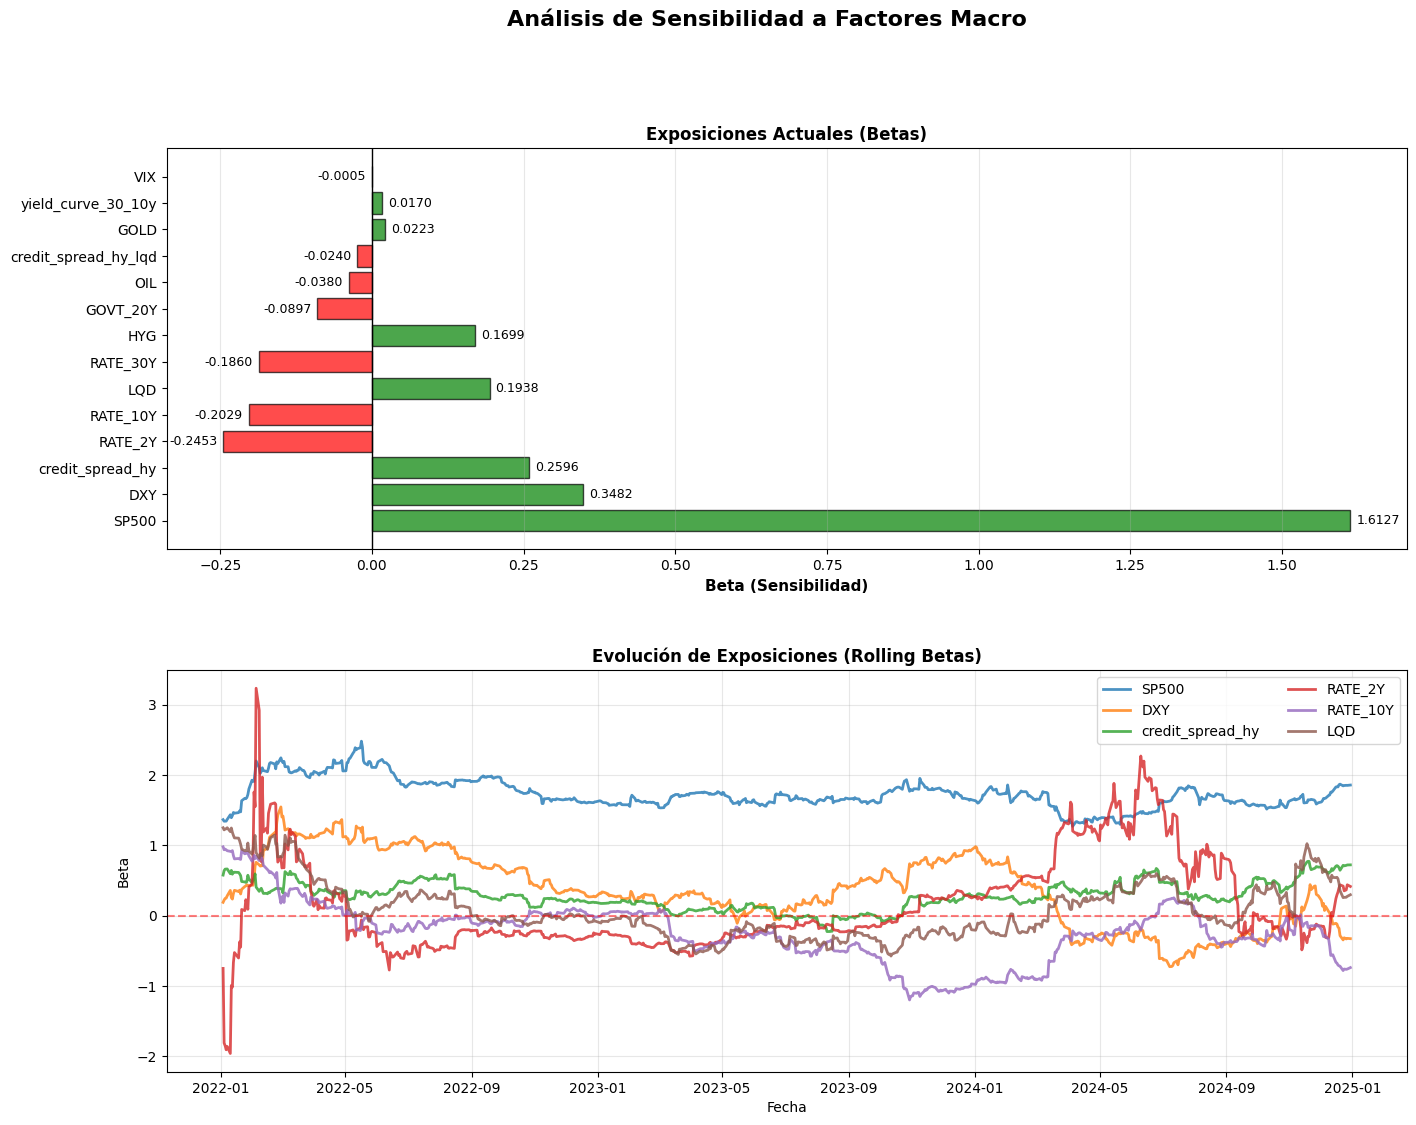

In [9]:
sens_results = sens_analyzer.analyze(
    portfolio_returns,
    factors_for_analysis
)

sens_reporter.print_analysis(sens_results)

rolling_betas = sens_analyzer.analyze_rolling(
    portfolio_returns,
    factors_for_analysis,
    window=REGIME_WINDOW
)

fig = sens_viz.plot_sensitivity_analysis(sens_results, rolling_betas=rolling_betas)
plt.show()

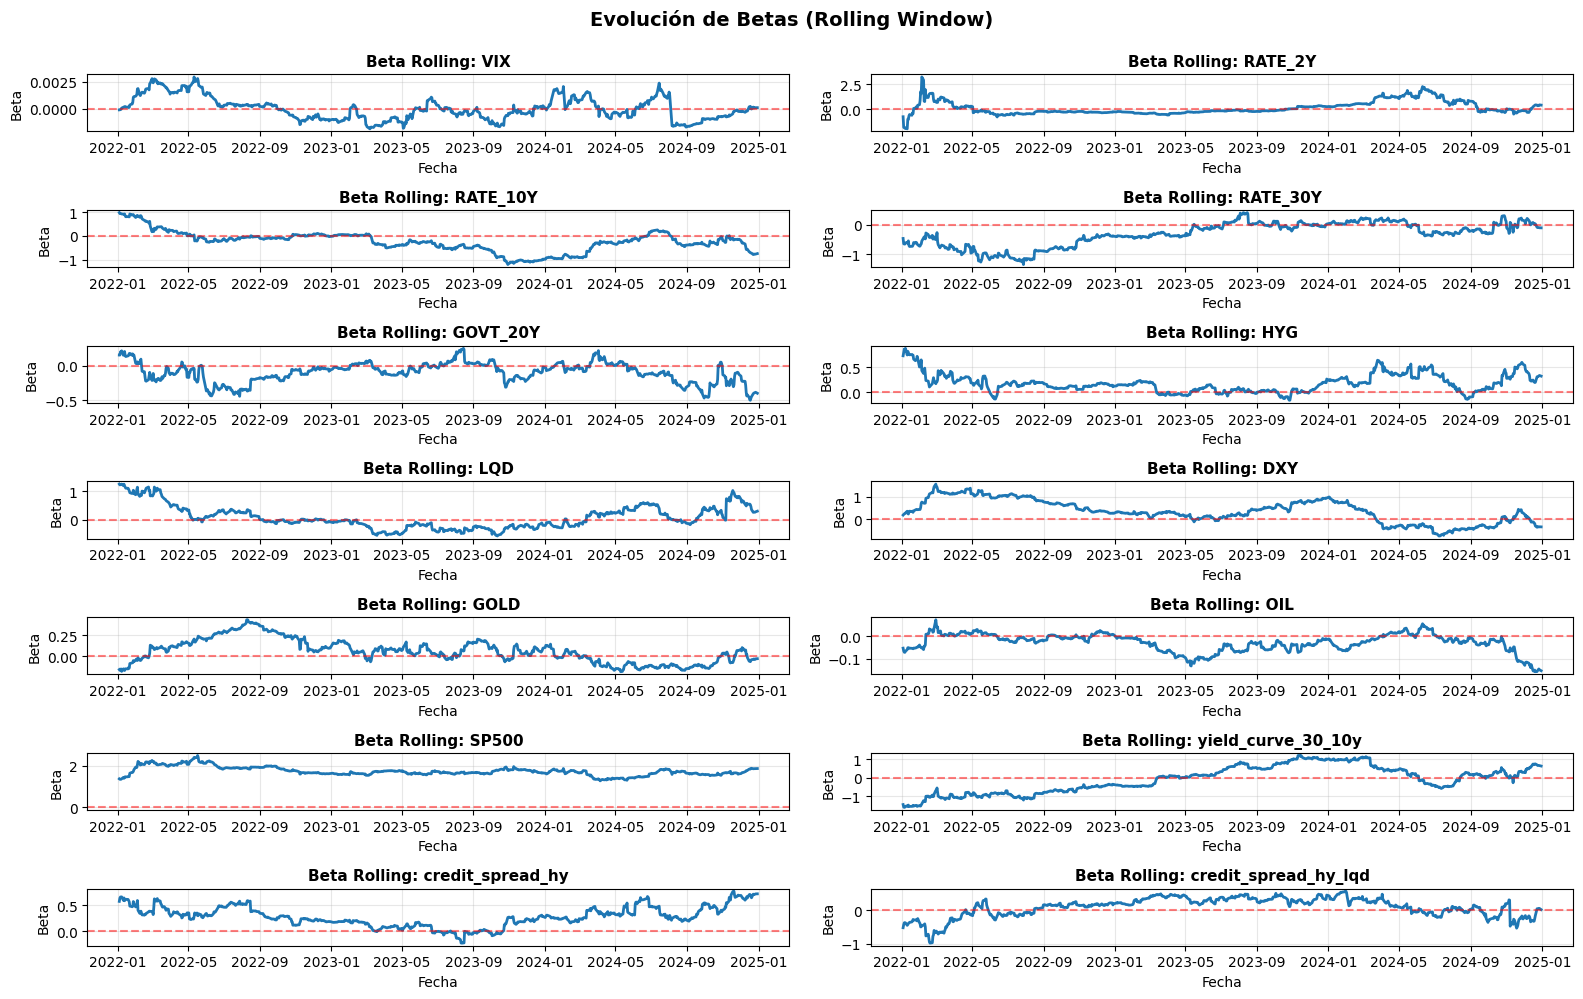

                      ANÁLISIS DE FACTORES MACRO                      
RESUMEN DE REGRESIÓN
  Alpha (diario):             0.1314%
  Alpha (anual):               39.22%
  R²:                          0.399
  R² ajustado:                 0.392
  Observaciones:                1003
  Interpretación:           Excelente - genera alpha significativo
FACTOR LOADINGS (BETAS)
Factor                     Beta     t-stat    p-value Signif    
SP500                    1.6127     10.183     0.0000 ***       
HYG                      0.4056      1.489     0.1365           
GOVT_20Y                -0.3494     -1.350     0.1772           
DXY                      0.3482      1.442     0.1493           
RATE_2Y                 -0.2453     -1.170     0.2421           
RATE_10Y                -0.2199     -0.402     0.6880           
LQD                      0.2178      0.463     0.6435           
RATE_30Y                -0.1690     -0.320     0.7490           
OIL                     -0.0380     -1.408   

In [10]:
fig = sens_viz.plot_rolling_betas(rolling_betas, figsize=(16, 10))
plt.show()
factor_reporter.print_analysis(factor_results)

                        SITUACIÓN MACROECONÓMICA GLOBAL                         
RESUMEN EJECUTIVO

  Nivel de riesgo global: 🔴 ALTO

  Factores de riesgo detectados:
    • Expectativas inflacionarias elevadas
    • Inflación moderada-alta
    • Fuerte presión inflacionaria (metales)
    • Presión en bonos USA
    • Dólar debilitándose
CURVA DE TIPOS DE INTERÉS (USA)

  Niveles actuales:
     10Y:   4.55%
      2Y:   4.18%
     30Y:   4.76%
      5Y:   4.37%

  Spreads:
    🟢     10Y-2Y:  +0.36 pp
    🟢     10Y-5Y:  +0.18 pp
    🟢    30Y-10Y:  +0.22 pp

  Cambios en tasas:
    Tenor  1 Mes        3 Meses      1 Año       
    10Y     +0.37 pp     +0.80 pp     +0.68 pp   
    2Y      -0.19 pp     -0.30 pp     -1.00 pp   
    30Y     +0.40 pp     +0.68 pp     +0.74 pp   
    5Y      +0.32 pp     +0.85 pp     +0.53 pp   

  📊 Divergencia Corto vs Largo Plazo:
    3 meses:
      Corto (2Y):  -0.30 pp
      Largo (10Y):  +0.80 pp
      Divergencia:  +1.10 pp 🔴 (Largo sube más que corto - ex

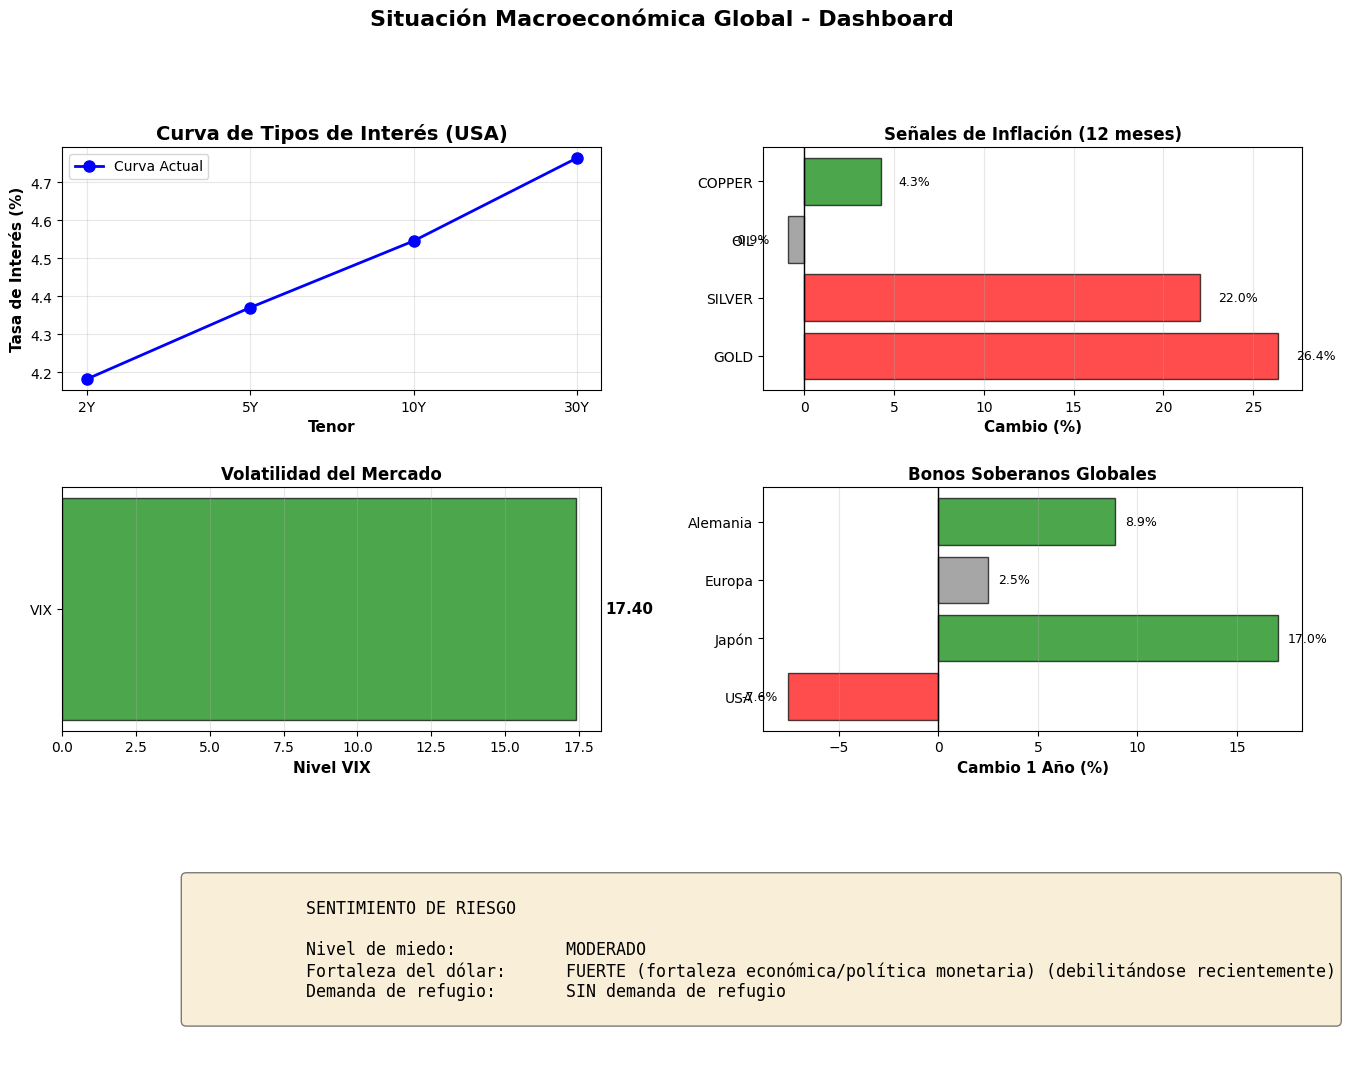

In [11]:
situation_results = situation_analyzer.analyze(factors_raw)
situation_reporter.print_situation(situation_results)
fig = situation_viz.plot_macro_situation(situation_results)
plt.show()